# Examen 1 - Métodos estadísticos Bayesianos

![](https://upload.wikimedia.org/wikipedia/commons/1/18/Bayes%27_Theorem_MMB_01.jpg)

# OWEN DAVID LOZA QUIRARTE
# 751563

## 1. Sobreventa en aerolíneas (60 puntos)

Supongamos que usted es la (el) encargad@ de la estrategia comercial de una aerolínea. Dado que las cancelaciones en los boletos y los pasajeros que no se presentan el día del vuelo es un asunto bastante recurrente, usted se plantea sobrevender los vuelos. La idea de la sobreventa es simple:

> Vendemos más boletos de los que en realidad tenemos capacidad, esperando que después de las cancelaciones, las personas que se presenten el día del vuelo coincidan con el número de asientos disponibles del avión.

Para simplificar un poco todo el problema, consideremos un vuelo arbitrario. Dada la naturaleza de este problema, se tiene gran incertidumbre en **cuantas personas se presentarán el día del vuelo**, por lo que usaremos un modelo probabilístico para modelar esta situación. Supongamos que:

- Nuestro avión tiene una capacidad $C$ de asientos.
- La demanda es lo suficientemente alta como para que todos los boletos que ponemos a la venta $B$ se vendan. En una estrategia de sobreventa, $B > C$.
- La probabilidad de que una persona arbitraria se presente al vuelo es $\theta$.
- El número de personas que se presentan al vuelo es $X$.

Con lo anterior, podemos modelar la variable aleatoria $X$ del número de personas que se presentan al vuelo como una distribución $\text{Binomial}(B, \theta)$. Es decir, la probabilidad de que se presenten $i$ personas al vuelo es:

$$
p(X = i) = \left(\begin{array}{c}B \\ i \end{array}\right) \theta^i (1 - \theta)^{B-i}.
$$

Con estas definiciones, podemos hablar también en términos de negocio. Por ejemplo, ¿cuál sería el costo de la sobreventa?

Simplificando nuevamente el problema, supongamos que la tarifa de cada boleto es $T$ y es la misma para todos los $B$ boletos. Supongamos que en el caso de que una persona se presente al vuelo, y no pueda abordar, le devolvemos su dinero (o equivalentemente lo abordamos en el siguiente vuelo disponible) más $k$ veces el costo del boleto, es decir $(k + 1) T$. Entonces, los costos por sobreventa son:

$$
c_{ob} = T (k + 1) \max(X - C, 0)
$$

Finalmente, los ingresos del vuelo descontando los costos por sobreventa son:

$$
I = T B - T (k + 1) \max(X - C, 0).
$$

### 1.1. (30 puntos) Máxima verosimilitud

1. (10 puntos) Supongamos que tenemos un avión con capacidad de $C=200$ pasajeros, y hacemos una sobreventa de $B=220$ boletos. Al vuelo se presentan $208$ personas. Bajo estas condiciones, ¿Cuál es el estimador de máxima verosimilitud para $\theta$?

![fe1](fe1.jpg)

2. (10 puntos) Graficar la pmf $\text{Binomial}(B, \theta)$ con $B=220$ boletos y la $\theta$ estimada en el punto anterior.

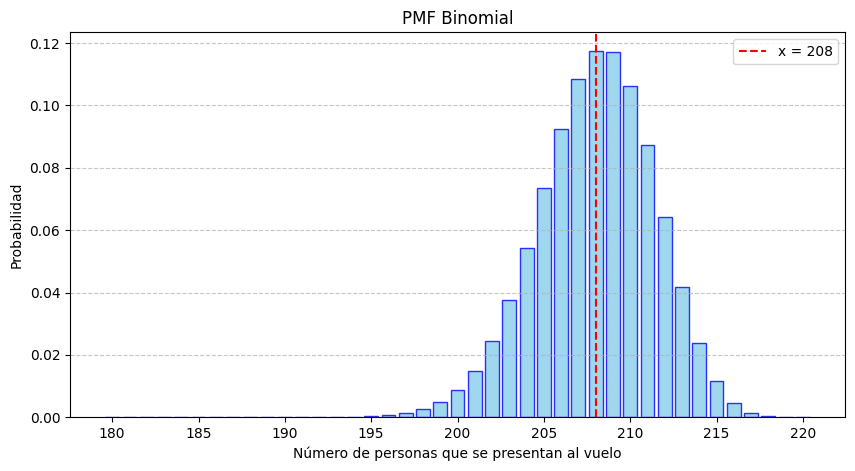

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# nuestros datos
B = 220
x = 208
theta_mle = x / B

# ponemos el rango en este para que la campana se vea mejor
rango = np.arange(180, 221)

# calculamos la PMF de la Binomial con binom de scipy
pmf_binomial = binom.pmf(rango, B, theta_mle)

# hacemos la gráfica
plt.figure(figsize=(10, 5))
plt.bar(rango, pmf_binomial, color='skyblue', edgecolor='blue', alpha=0.8)
plt.axvline(208, color='red', linestyle='--', label='x = 208')
plt.title(r'PMF Binomial')
plt.xlabel('Número de personas que se presentan al vuelo')
plt.ylabel('Probabilidad')
plt.xticks(np.arange(180, 221, 5))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

3. (10 puntos) Considerando una tarifa $T=1000$, y que por cada pasajero que se presente y sea dejado fuera del vuelo devolvemos una vez la tarifa $k=1$, ¿Cuál sería el costo por sobreventa?, ¿Cuál sería el ingreso descontando dicho costo?, ¿En retrospectiva, habrías ofertado una sobreventa menor?

![fe2](fe2.jpg)

**RESPONDIENDO A ESTA PREGUNTA**

¿En retrospectiva, habrías ofertado una sobreventa menor?

En resumen sí lo haría porque nos pasamos y tuvimos que pagar multas a esas 8 personas de más.

Si vemos en retrospectiva si hubiéramos vendido solamente 200 + 12 que sabíamos que iban a faltar entonces habríamos vendido solamente los exactos lugares que eran los 200 lugares que teníamos, no hubieramos tenido que pagar ninguna compensación y además habríamos alcanzado la máxima venta de todos los lugares.  

### 1.2. (10 puntos) Selección de previas

Alejándonos un poco del punto anterior, queremos hacer una modelación Bayesiana. Para esto debemos seleccionar una distribución previa adecuada, dependiendo del conocimiento previo que tengamos acerca de la probabilidad de que una persona se presente en el vuelo $\theta$.

1. (15 puntos) Supongamos que, en principio, no tenemos información alguna sobre $\theta$.
   - ¿Qué previa modela esta situación?
   - Supongamos que tenemos un avión con capacidad de $C=200$ pasajeros, y hacemos una sobreventa de $B=220$ boletos. Al vuelo se presentan $207$ personas. Utilice una tabla de actualización Bayesiana para encontrar la distribución posterior de $\theta$.
   - Graficar la previa y la posterior.
   - Considerando una tarifa $T=1000$, y que por cada pasajero que se presente y sea dejado fuera del vuelo devolvemos una vez la tarifa $k=1$, ¿Cuál sería el costo por sobreventa?, ¿Cuál sería el ingreso descontando dicho costo?, ¿En retrospectiva, habrías ofertado una sobreventa menor?

**RESPUESTA:**

Como no tenemos información previa sobre $\theta$ vamos a utilizar una distribución $\text{Uniforme}(0, 1)$, que es matemáticamente equivalente a una distribución **$\text{Beta}(1, 1)$**.

Como ya sabemos en las distribuciones $\text{Beta}$ es la previa conjugada para la verosimilitud Binomial, por ende en la actualización bayesiana sigue la regla de que si tenemos una previa $\text{Beta}(a, b)$ y datos con verosimilitud $\text{Binomial}(n, \theta)$, la posterior será una $\text{Beta}(a + X, b + n - X)$, ahora si sustituimos con nuestros datos ($n = 220$, $X = 207$), obtenemos esto: 

| Hipótesis | Datos | Previa | Verosimilitud | Numerador de Bayes | Posterior |
|-----------|-------|--------|---------------|--------------------|-----------|
| $$\theta$$ | $X=207, n=220$ | $$c_1\,\theta^{1-1}(1-\theta)^{1-1}$$ | $$\binom{220}{207}\theta^{207}(1-\theta)^{13}$$ | $$c\,\theta^{207}(1-\theta)^{13}$$ | $$\text{Beta}(208,14)$$ |

Entonces sabemos que la distribución posterior actualizada para $\theta$ es una **$\text{Beta}(208, 14)$**.

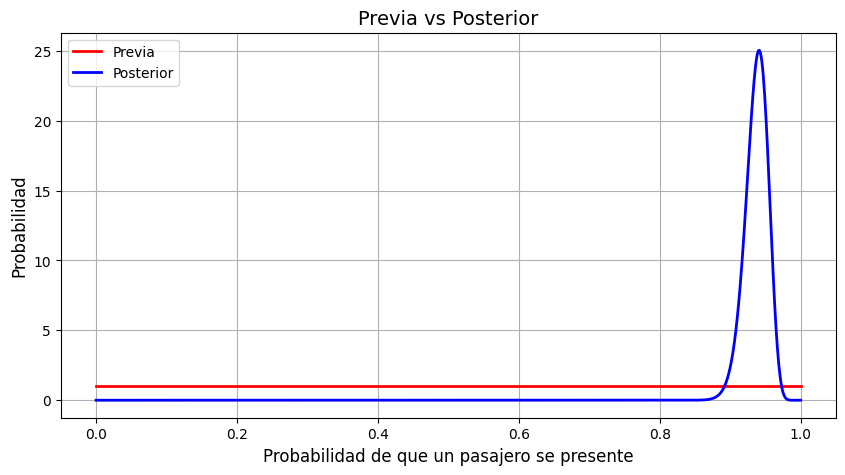

In [32]:
# nuestra gráfica de la previa y posterior
from scipy import stats

theta = np.linspace(0, 1, 1000)

previa = stats.beta.pdf(theta, 1, 1)
posterior = stats.beta.pdf(theta, 208, 14)


plt.figure(figsize=(10, 5))
plt.plot(theta, previa, label='Previa', color='red', linewidth=2)
plt.plot(theta, posterior, label='Posterior', color='blue', linewidth=2)
plt.title('Previa vs Posterior', fontsize=14)
plt.xlabel(r'Probabilidad de que un pasajero se presente', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

2. (15 puntos) Usando la posterior del punto anterior como previa, supongamos ahora que hacemos una sobreventa de $B=215$ boletos, y se presentan $198$ personas.
   - Utilice una tabla de actualización Bayesiana para encontrar la distribución posterior de $\theta$.
   - Graficar la previa y la posterior.
   - Considerando una tarifa $T=1000$, y que por cada pasajero que se presente y sea dejado fuera del vuelo devolvemos una vez la tarifa $k=1$, ¿Cuál sería el costo por sobreventa?, ¿Cuál sería el ingreso descontando dicho costo?, ¿En retrospectiva, habrías ofertado una sobreventa menor?

**RESPUESTA:**

Para este segundo vuelo nuestra nueva previa es una **$\text{Beta}(208, 14)$**.

Aplicamos los mismos conceptos de actualización bayesiana y nos queda esta tabla: 

| Hipótesis | Datos | Previa | Verosimilitud | Numerador de Bayes | Posterior |
| :---: | :---: | :---: | :---: | :---: | :---: |
| $\theta$ | $X=198, n=215$ | $c_1 \theta^{208-1}(1 - \theta)^{14-1}$ | $\binom{215}{198} \theta^{198} (1-\theta)^{17}$ | $c_2 \theta^{405} (1-\theta)^{30}$ | $\text{Beta}(406, 31)$ |

Entonces sabemos que la posterior actualizada para $\theta$ después de este segundo vuelo es una **$\text{Beta}(406, 31)$**.

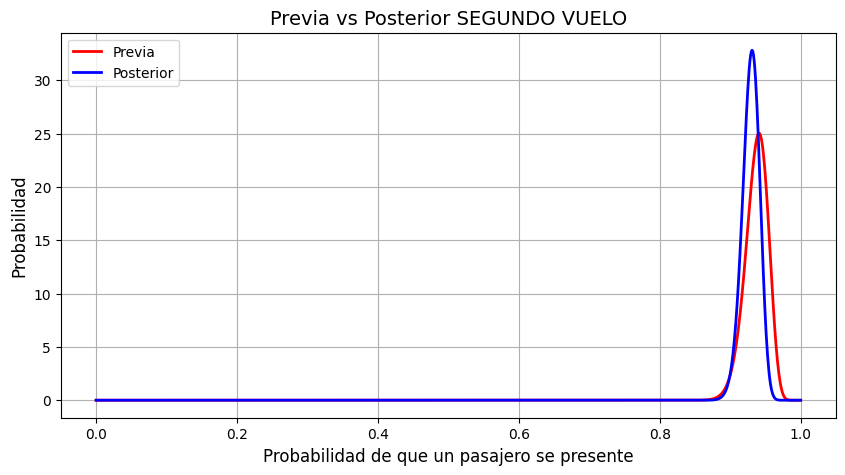

In [33]:
# nuestra gráfica de la previa y posterior de segundo vuelo 

theta = np.linspace(0, 1, 1000)

previa = stats.beta.pdf(theta, 208, 14)
posterior = stats.beta.pdf(theta, 406, 31)


plt.figure(figsize=(10, 5))
plt.plot(theta, previa, label='Previa', color='red', linewidth=2)
plt.plot(theta, posterior, label='Posterior', color='blue', linewidth=2)
plt.title('Previa vs Posterior SEGUNDO VUELO', fontsize=14)
plt.xlabel(r'Probabilidad de que un pasajero se presente', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

## 2. Regresión polinomial (40 puntos)

Considere el dataset (sintético) en `grades_data.csv`.

Consideremos la situación en la cual queremos predecir la nota del examen [grades] (0-100%) a partir del número de horas estudiadas por día [study_time]

### 2.1. (10 puntos)

Lleve a cabo un análisis exploratorio de datos, donde explore potenciales relaciones entre las variables `grade` y `study_time`.

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos los datos
df = pd.read_csv('grades_data.csv')
df

,study_time,grades
0,1.000000,31.768501
1,1.018036,20.016187
2,1.036072,34.541517
3,1.054108,20.829142
4,1.072144,13.256199
...,...,...
495,9.927856,52.391326
496,9.945892,42.111070
497,9.963928,41.820074
498,9.981964,50.946761


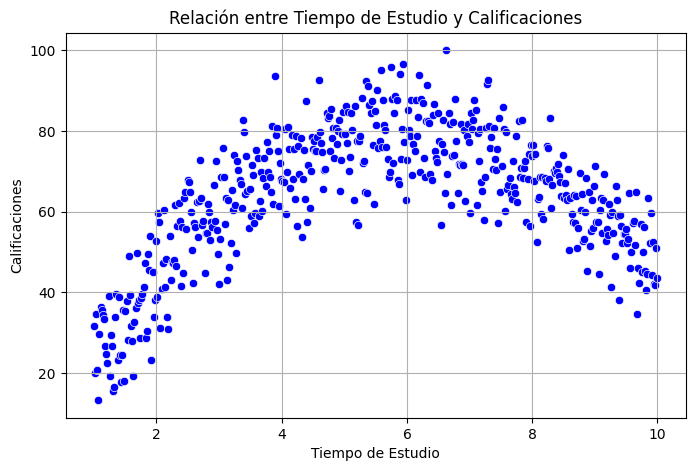

In [35]:
# Hacemos un ScatterPlot para ver la distribución de los datos
plt.figure(figsize=(8, 5))
sns.scatterplot(x='study_time', y='grades', data=df, color='blue')
plt.title('Relación entre Tiempo de Estudio y Calificaciones')
plt.xlabel('Tiempo de Estudio')
plt.ylabel('Calificaciones')
plt.grid(True)
plt.show()

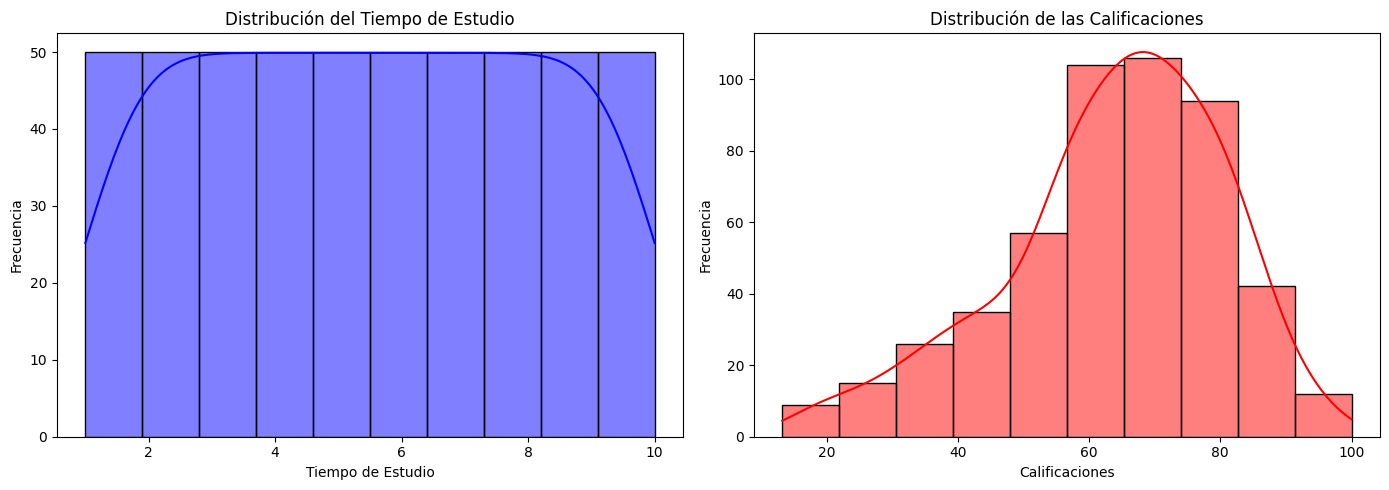

In [36]:
# vamos a hacer ahora un histograma para ver la distribución tanto de las calificaciones como del tiempo de estudio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['study_time'], bins=10, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribución del Tiempo de Estudio')
axes[0].set_xlabel('Tiempo de Estudio')
axes[0].set_ylabel('Frecuencia')
sns.histplot(df['grades'], bins=10, kde=True, color='red', ax=axes[1])
axes[1].set_title('Distribución de las Calificaciones')
axes[1].set_xlabel('Calificaciones')
axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


### 2.2. (10 puntos)

Usaremos un modelo polinomial para la tarea de predicción. Elige un grado de polinomio adecuado de acuerdo a tu conclusión en el punto 2.1

**RESPUESTA:**

Vamos a elegir usar un Grado 2

Esto debido a que como se observa en nuestro diagrama de dispersión o Scatter Plot la relación entre las horas de estudio y las calificaciones no conforman una línea recta, los datos nos forman una pequeña curva como si fuese una parábola por lo que un grado 1 haría que nuestro modelo sufriese un underfitting y no estaríamos captando la tendencia real del problema que tenemos enfrente.

Y no escogemos más porque no es necesario, en todo caso estaríamos probablemente cayendo en overfitting entonces un grado 2 es más que suficiente. 



### 2.3. (10 puntos)

Dividir los datos en datos de entrenamiento, y datos de prueba.

Con los datos de entrenamiento, encontrar los coeficientes de máxima verosimilitud para el polinomio.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# separamos X y Y
X = df[['study_time']]
y = df['grades']

# dividimos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# construimos el pipeline para regresión polinomial
polymodel = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# entrenamos el modelo
polymodel.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly_features', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [38]:
# nos metemos al regressor para obtener los coeficientes

coeficientes = polymodel.named_steps['regressor'].coef_
coeficientes

array([ 67.07571869, -62.82571198])

### 2.4. (10 puntos)

Evalúa el modelo entrenado, usando la métrica de $R^2$, tanto en el dataset de entrenamiento como en el que reservaste para pruebas.

In [39]:
# y ya solo evaluamos
print(f'Score (Train): {polymodel.score(X_train, y_train):.2f}')

print(f'Score (Test): {polymodel.score(X_test, y_test):.2f}')

Score (Train): 0.73
Score (Test): 0.80


Y listo!! Podemos ver que el modelo está generalizando bien y no parece tener signos de overfitting

<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Esteban Jiménez Rodríguez.
</footer>